In [30]:
from google.colab import drive
import pandas as pd
import os
import ast
import torch

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
import torch
import torch.nn as nn
import timm
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


DRIVE_DATA_DIR = "/content/drive/MyDrive//Data"
LOCAL_DATA_DIR = "/content/data"

!mkdir -p {LOCAL_DATA_DIR}

!cp -r "{DRIVE_DATA_DIR}/images_001" {LOCAL_DATA_DIR}/
!cp -r "{DRIVE_DATA_DIR}/images_002" {LOCAL_DATA_DIR}/
!cp -r "{DRIVE_DATA_DIR}/processed" {LOCAL_DATA_DIR}/


def parse_encoded_labels(label_str):
    """Parses space-separated strings like '[0 0 1]' into Python lists."""
    return [int(x) for x in label_str.strip("[]").split()]

PROCESSED_LOCAL = os.path.join(LOCAL_DATA_DIR, "processed")

train_df = pd.read_csv(os.path.join(PROCESSED_LOCAL, "train.csv"),
                       converters={'encoded_labels': parse_encoded_labels})
val_df = pd.read_csv(os.path.join(PROCESSED_LOCAL, "val.csv"),
                     converters={'encoded_labels': parse_encoded_labels})
test_df = pd.read_csv(os.path.join(PROCESSED_LOCAL, "test.csv"),
                      converters={'encoded_labels': parse_encoded_labels})


train_df['image_path'] = train_df['image_path'].str.replace(DRIVE_DATA_DIR, LOCAL_DATA_DIR)
val_df['image_path'] = val_df['image_path'].str.replace(DRIVE_DATA_DIR, LOCAL_DATA_DIR)
test_df['image_path'] = test_df['image_path'].str.replace(DRIVE_DATA_DIR, LOCAL_DATA_DIR)

print(f"\n Loaded {len(train_df)} training images.")
print(f"Verified local path: {train_df.iloc[0]['image_path']}")
print(f"Verified label format: {train_df.iloc[0]['encoded_labels']}")

🚀 Starting data migration to local SSD...

✅ Success! Loaded 4996 training images.
Verified local path: /content/drive/MyDrive/Data/images_002/images/00002774_000.png
Verified label format: [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]


In [37]:
import pandas as pd

CLASSES_PATH = "/content/drive/MyDrive/Data/processed/label_classes.csv"

try:
    classes_df = pd.read_csv(CLASSES_PATH)
    class_names = classes_df['label_name'].tolist()
    print(f"Loaded {len(class_names)} class names successfully.")
except FileNotFoundError:
    class_names = [
        'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass',
        'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema',
        'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia'
    ]
    print("CSV not found.")

✅ Loaded 14 class names successfully.


#Dataset

In [32]:
class NIHDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['image_path']
        label = torch.tensor(self.df.iloc[idx]['encoded_labels'], dtype=torch.float32)

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_loader = DataLoader(NIHDataset(train_df, transform=transform), batch_size=256, shuffle=True,num_workers=8, pin_memory=True)
val_loader = DataLoader(NIHDataset(val_df, transform=transform), batch_size=256,num_workers=8, pin_memory=True)

#ViT

In [33]:
import torch
import torch.nn as nn
import timm

class ViTFrozenBackbone(nn.Module):
    def __init__(self, num_classes=14):
        super(ViTFrozenBackbone, self).__init__()
        self.model = timm.create_model('vit_base_patch16_224', pretrained=True)

        for param in self.model.parameters():
            param.requires_grad = False

        n_features = self.model.head.in_features
        self.model.head = nn.Linear(n_features, num_classes)

    def forward(self, x):
        return self.model(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ViTFrozenBackbone(num_classes=14).to(device)

In [42]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"total parameters: {total_params:,}")
print(f"Trainable Parameters (the head): {trainable_params:,}")

total parameters: 85,809,422
Trainable Parameters (the head): 10,766


In [47]:
from torch.cuda.amp import GradScaler, autocast

train_loader = DataLoader(NIHDataset(train_df, transform=transform),
                          batch_size=256, shuffle=True, num_workers=8, pin_memory=True)
val_loader = DataLoader(NIHDataset(val_df, transform=transform),
                        batch_size=256, num_workers=8, pin_memory=True)

scaler = GradScaler()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

def train_epoch():
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
    return total_loss / len(train_loader)

for epoch in range(2):
    loss = train_epoch()
    print(f"Epoch {epoch+1} Complete | Avg Loss: {loss:.4f}")

torch.save(model.state_dict(), "vit_base_nih_results_01.pth")
print("Model saved! You have your base results for tonight.")

/tmp/ipykernel_733/1244541204.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_733/1244541204.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1 Complete | Avg Loss: 0.2410
Epoch 2 Complete | Avg Loss: 0.2374
Epoch 3 Complete | Avg Loss: 0.2385
Epoch 4 Complete | Avg Loss: 0.2376
Epoch 5 Complete | Avg Loss: 0.2376
Epoch 6 Complete | Avg Loss: 0.2359
Epoch 7 Complete | Avg Loss: 0.2357
Epoch 8 Complete | Avg Loss: 0.2362
Epoch 9 Complete | Avg Loss: 0.2353
Epoch 10 Complete | Avg Loss: 0.2347
Epoch 11 Complete | Avg Loss: 0.2342
Epoch 12 Complete | Avg Loss: 0.2345
Epoch 13 Complete | Avg Loss: 0.2346
Epoch 14 Complete | Avg Loss: 0.2349
Epoch 15 Complete | Avg Loss: 0.2344
Epoch 16 Complete | Avg Loss: 0.2333
Epoch 17 Complete | Avg Loss: 0.2343
Epoch 18 Complete | Avg Loss: 0.2336
Epoch 19 Complete | Avg Loss: 0.2328
Epoch 20 Complete | Avg Loss: 0.2330
Epoch 21 Complete | Avg Loss: 0.2334
Epoch 22 Complete | Avg Loss: 0.2318
Epoch 23 Complete | Avg Loss: 0.2316
Epoch 24 Complete | Avg Loss: 0.2316
Epoch 25 Complete | Avg Loss: 0.2315
Epoch 26 Complete | Avg Loss: 0.2310
Epoch 27 Complete | Avg Loss: 0.2310
Epoch 28 C

In [48]:
import torch
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_fscore_support, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns

def get_all_preds(model, dataloader):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            logits = model(images)
            probs = torch.sigmoid(logits)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())

    return np.vstack(all_probs), np.vstack(all_labels)

test_loader = DataLoader(NIHDataset(test_df, transform=transform), batch_size=256)
probs, labels = get_all_preds(model, test_loader)

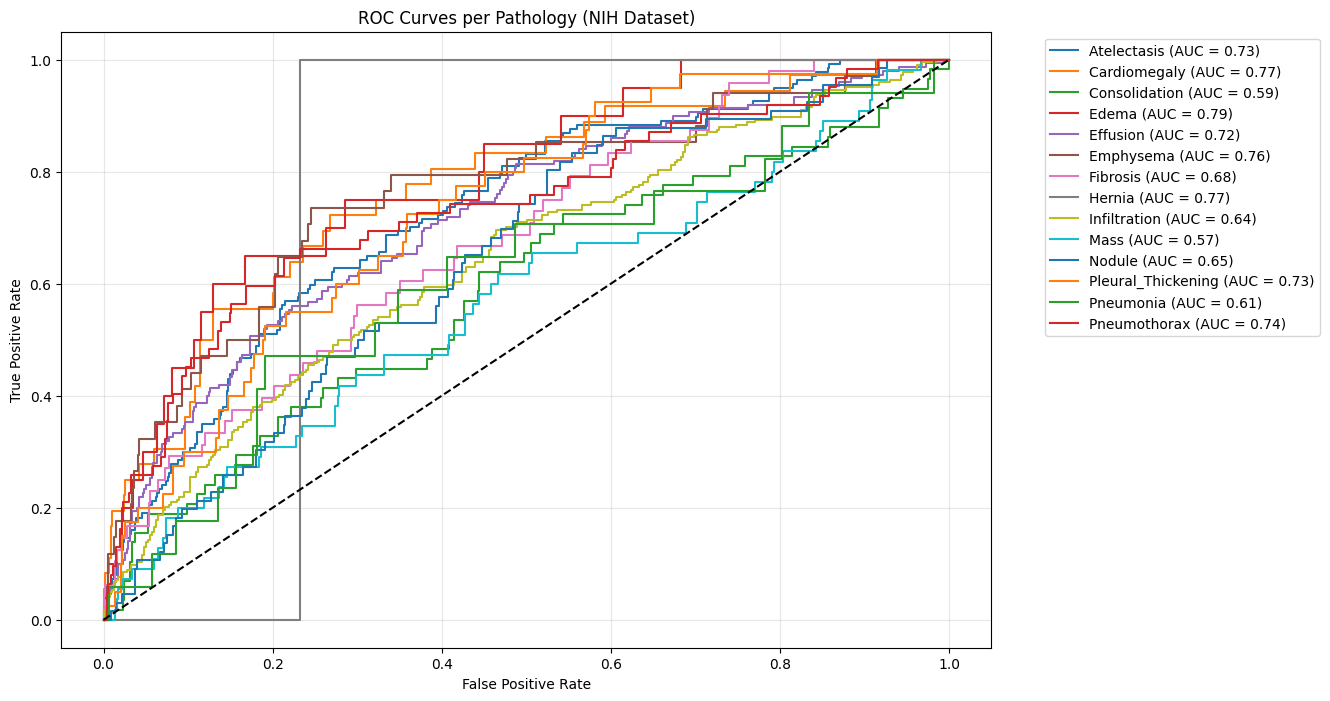


Mean AUC-ROC: 0.6967


In [49]:
plt.figure(figsize=(12, 8))
auc_scores = []

for i, name in enumerate(class_names):
    # Calculate AUC for each class
    try:
        auc = roc_auc_score(labels[:, i], probs[:, i])
        auc_scores.append(auc)

        fpr, tpr, _ = roc_curve(labels[:, i], probs[:, i])
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')
    except ValueError:
        continue

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves per Pathology (NIH Dataset)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.show()

print(f"\nMean AUC-ROC: {np.mean(auc_scores):.4f}")

In [50]:
from sklearn.metrics import classification_report

# Convert probabilities to binary predictions using 0.5 threshold
preds = (probs > 0.5).astype(int)

report = classification_report(
    labels,
    preds,
    target_names=class_names,
    zero_division=0
)

print("### Multi-Label Classification Report ###")
print(report)

mAP = average_precision_score(labels, probs, average="macro")
print(f"Mean Average Precision (mAP): {mAP:.4f}")

### Multi-Label Classification Report ###
                    precision    recall  f1-score   support

       Atelectasis       0.54      0.18      0.27       137
      Cardiomegaly       0.35      0.19      0.25        36
     Consolidation       0.00      0.00      0.00        58
             Edema       0.22      0.10      0.14        20
          Effusion       0.55      0.33      0.41       150
         Emphysema       0.38      0.15      0.21        34
          Fibrosis       0.35      0.15      0.21        48
            Hernia       0.00      0.00      0.00         1
      Infiltration       0.58      0.25      0.35       224
              Mass       0.00      0.00      0.00        55
            Nodule       0.15      0.03      0.05        66
Pleural_Thickening       0.25      0.03      0.05        40
         Pneumonia       0.00      0.00      0.00        17
      Pneumothorax       0.38      0.26      0.31        62

         micro avg       0.47      0.18      0.26       

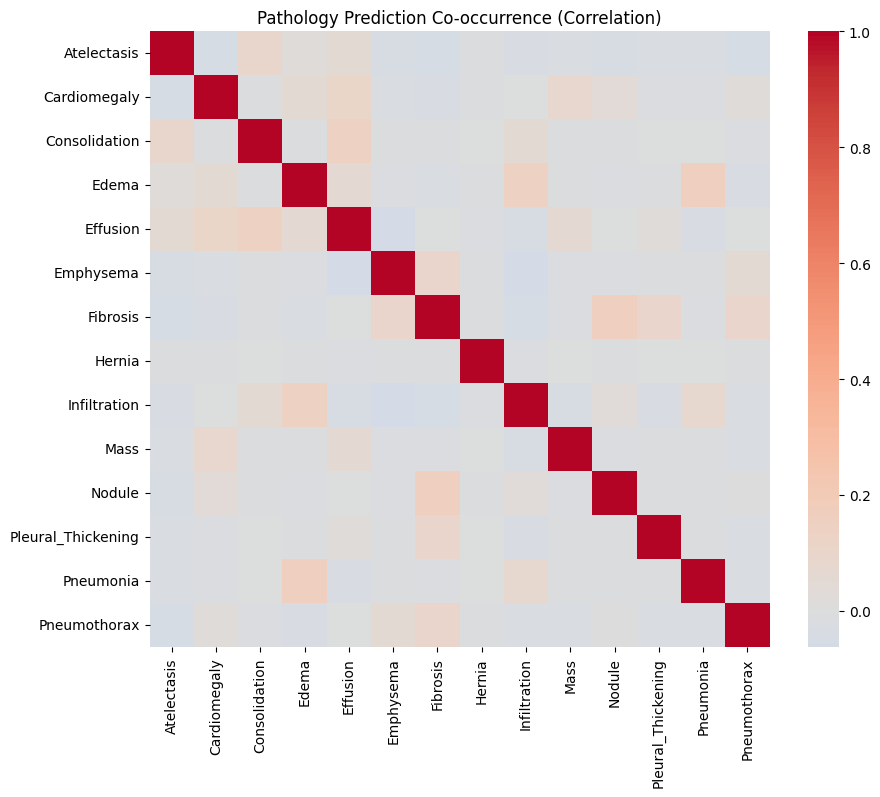

In [51]:
pred_df = pd.DataFrame(preds, columns=class_names)
correlation = pred_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=False, cmap='coolwarm', center=0)
plt.title("Pathology Prediction Co-occurrence (Correlation)")
plt.show()